In [86]:
import math
import os
import csv
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [87]:
SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


                 date  target
0 2025-01-01 00:00:00   98.14
1 2025-01-01 01:00:00   98.07
2 2025-01-01 02:00:00  104.70
3 2025-01-01 03:00:00  112.81
4 2025-01-01 04:00:00  112.62
         count                 mean                  min                  25%                  50%                  75%  \
date      4320  2025-03-31 23:30:00  2025-01-01 00:00:00  2025-02-14 23:45:00  2025-03-31 23:30:00  2025-05-15 23:15:00   
target  4320.0            135.60584                 69.1             120.5375              135.835              150.625   

                        max        std  
date    2025-06-29 23:00:00        NaN  
target                210.1  21.384633  
Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00


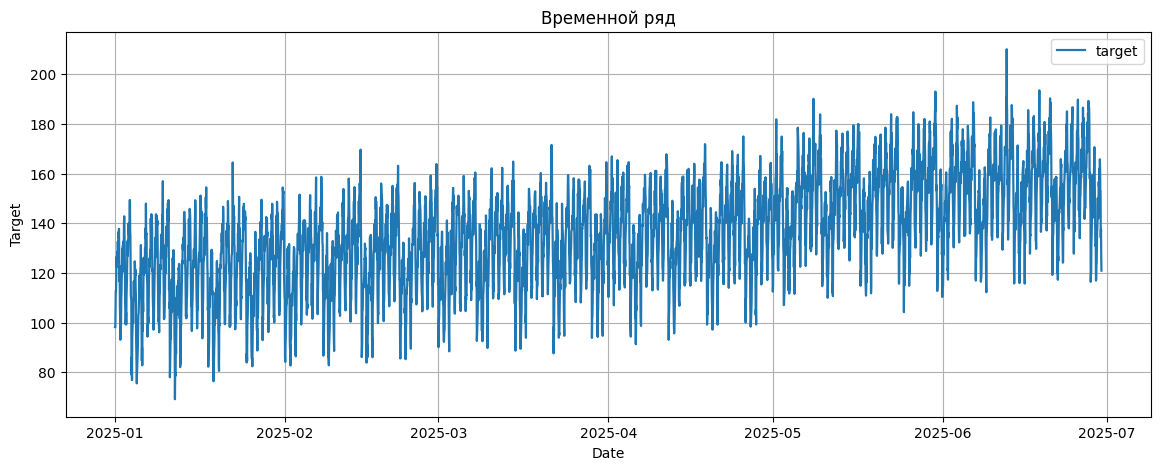

In [88]:
df = pd.read_csv("data/S12-hw-dataset.csv")
df['date'] = pd.to_datetime(df['date'])

print(df.head())
print(df.describe(include="all").T) # показывает число записей и пропусков
print(f"Диапазон дат: {df["date"].min()} - {df["date"].max()}")

fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], lw=1.6, label="target")
ax.set_title("Временной ряд")
ax.set_ylabel("Target")
ax.set_xlabel("Date")
ax.legend()
plt.show()

Ряд имеет восходящий тренд с периодическими недельными повышениями значения target. Присутствует шум и резкие скачки.

In [89]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70  # 70% для обучения
    val_frac: float = 0.15    # 15% для валидации, остальное для теста

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()          # Ранний период
    val_df = df.iloc[train_end:val_end].copy()     # Средний период
    test_df = df.iloc[val_end:].copy()             # Поздний период
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df.shape}, {train_df['date'].min().date()} -> {train_df['date'].max().date()}")
print(f"val  : {val_df.shape}, {val_df['date'].min().date()} -> {val_df['date'].max().date()}")
print(f"test : {test_df.shape}, {test_df['date'].min().date()} -> {test_df['date'].max().date()}")

train: (3024, 2), 2025-01-01 -> 2025-05-06
val  : (648, 2), 2025-05-07 -> 2025-06-02
test : (648, 2), 2025-06-03 -> 2025-06-29


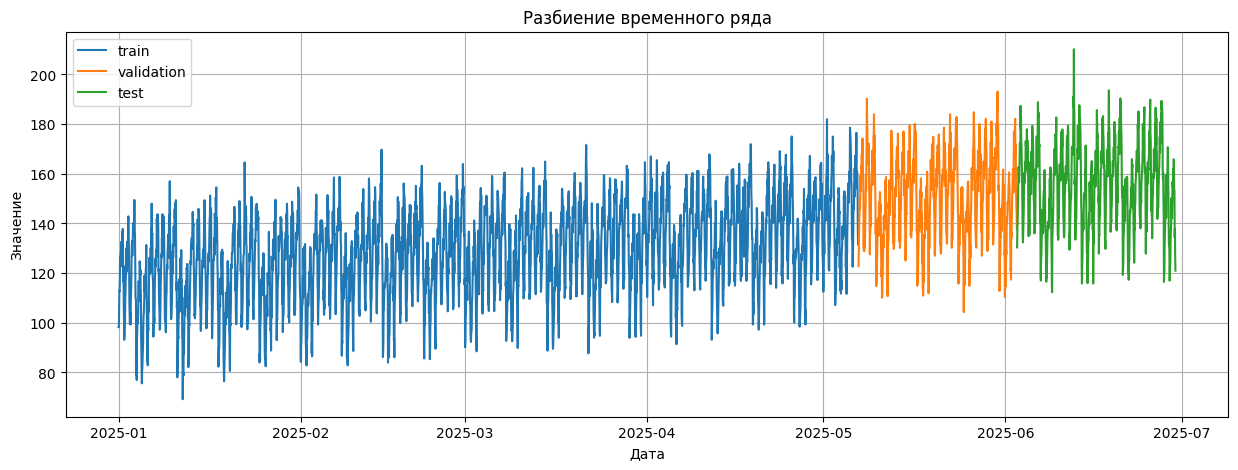

In [90]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")
ax.set_title("Разбиение временного ряда")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.savefig("artifacts/figures/series_split.png")
plt.show()

Random split некорретен для временных рядов, потому что он перемешивает значения. Моделоь будет учиться на смешанных данных из прошлого и будущего, что не соответствует задаче предсказания будущего используя только прошлое.

In [91]:
def add_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()

    out["dayofweek"] = out["date"].dt.dayofweek

    for lag in [1, 7, 14]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    # Перед rolling используем shift(1), чтобы статистика не включала текущее наблюдение.
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    return out

features_df = add_features(df)
features_df = features_df.dropna().reset_index(drop=True)
features_df.head(20)

,date,target,dayofweek,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
0,2025-01-01 14:00:00,128.87,2,125.04,126.01,98.14,126.445714,3.275621
1,2025-01-01 15:00:00,136.40,2,128.87,122.38,98.07,126.854286,3.388632
2,2025-01-01 16:00:00,133.85,2,136.40,128.28,104.70,128.857143,4.318919
3,2025-01-01 17:00:00,137.71,2,133.85,124.43,112.81,129.652857,4.691868
4,2025-01-01 18:00:00,126.32,2,137.71,126.35,112.62,131.550000,4.907936
5,2025-01-01 19:00:00,116.59,2,126.32,132.63,117.29,131.545714,4.913244
6,2025-01-01 20:00:00,122.83,2,116.59,125.04,126.50,129.254286,7.422746
7,2025-01-01 21:00:00,106.54,2,122.83,128.87,126.01,128.938571,7.674595
8,2025-01-01 22:00:00,101.72,2,106.54,136.40,122.38,125.748571,11.429896
9,2025-01-01 23:00:00,93.04,2,101.72,133.85,128.28,120.794286,13.391289


In [92]:
# Собираем финальный набор признаков для baseline-моделей.
feature_cols = [
    "dayofweek",
    "lag_1", "lag_7", "lag_14", 
    "rolling_mean_7", "rolling_std_7"
]

target_col = "target"

# Разбиение выполняем после построения признаков, но без перемешивания по времени.
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print("Размерности:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

Размерности:
X_train: (3014, 6) | y_train: (3014,)
X_val:   (646, 6) | y_val:   (646,)
X_test:  (646, 6) | y_test:  (646,)


In [93]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)


def evaluate_regression(y_true, y_pred) -> dict:
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
    }


def save_results(res: dict, file="artifacts/runs.csv"):
    fieldnames = [
        "experiment_id", "task", "dataset", "seed", "split_summary", "window_size", "horizon", "model_summary",
        "features_summary", "scaler", "optimizer", "lr", "epochs_trained", "best_val_mae", "best_val_rmse", "best_val_mape",
        "test_mae", "test_rmse", "test_mape", "notes"
    ]

    file_exists = os.path.isfile(file)

    with open(file, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)

        if not file_exists:
            writer.writeheader()
        
        writer.writerow(res)

In [94]:
experiment_id = "B1"

val_pred_naive = val_feat["lag_1"].to_numpy()
metrics_b1 = evaluate_regression(y_val, val_pred_naive)
save_results({
    "experiment_id": experiment_id, 
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": "temporal split 70/15/15", 
    "window_size": "",
    "horizon": "", 
    "model_summary": "naive-last",
    "features_summary": "dayofweek, lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7", 
    "scaler": "", 
    "optimizer": "", 
    "lr": "", 
    "epochs_trained": "", 
    "best_val_mae": metrics_b1['MAE'], 
    "best_val_rmse": metrics_b1['RMSE'], 
    "best_val_mape": metrics_b1['MAPE'],
    "test_mae" : "",
    "test_rmse" : "",
    "test_mape": "", 
    "notes": ""
})

In [95]:
experiment_id = "B2"

val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()
metrics_b2 = evaluate_regression(y_val, val_pred_ma7)
save_results({
    "experiment_id": experiment_id, 
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": "temporal split 70/15/15", 
    "window_size": "",
    "horizon": "", 
    "model_summary": "moving-average",
    "features_summary": "dayofweek, lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7", 
    "scaler": "", 
    "optimizer": "", 
    "lr": "", 
    "epochs_trained": "", 
    "best_val_mae": metrics_b2['MAE'], 
    "best_val_rmse": metrics_b2['RMSE'], 
    "best_val_mape": metrics_b2['MAPE'],
    "test_mae" : "",
    "test_rmse" : "",
    "test_mape": "", 
    "notes": ""
})

In [96]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
experiment_id = "B3"

ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train_scaled, y_train)

val_pred_ridge = ridge.predict(X_val_scaled)
metrics_b3 = evaluate_regression(y_val, val_pred_ridge)
save_results({
    "experiment_id": experiment_id, 
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": "temporal split 70/15/15", 
    "window_size": "",
    "horizon": "", 
    "model_summary": "ridge-lag-features",
    "features_summary": "dayofweek, lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7", 
    "scaler": "StandartScaler", 
    "optimizer": "", 
    "lr": "", 
    "epochs_trained": "", 
    "best_val_mae": metrics_b3['MAE'], 
    "best_val_rmse": metrics_b3['RMSE'], 
    "best_val_mape": metrics_b3['MAPE'],
    "test_mae" : "",
    "test_rmse" : "",
    "test_mape": "", 
    "notes": ""
})


In [98]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)

window_size = 24 * 7 # 1 неделя

def make_windows(series_2d: np.ndarray, window_size: int):
    """
    Преобразует временной ряд в обучающие примеры вида (X, y).
    Каждый пример X: окно из window_size значений
    Каждый пример y: следующее значение после окна
    Например: X = [day1..day28], y = day29
    """
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])
        y.append(series_2d[i + window_size, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Создаем обучающие примеры для каждого набора
X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled, window_size)
X_test, y_test = make_windows(test_scaled, window_size)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (2856, 168, 1) y_train: (2856,)
X_val  : (480, 168, 1) y_val  : (480,)
X_test : (480, 168, 1) y_test : (480,)


Форма одного окна: (168, 1)
Первые 5 значений окна: [-1.6267993  -1.6305869  -1.2718506  -0.8330344  -0.84331495]
Цель: -1.6825306


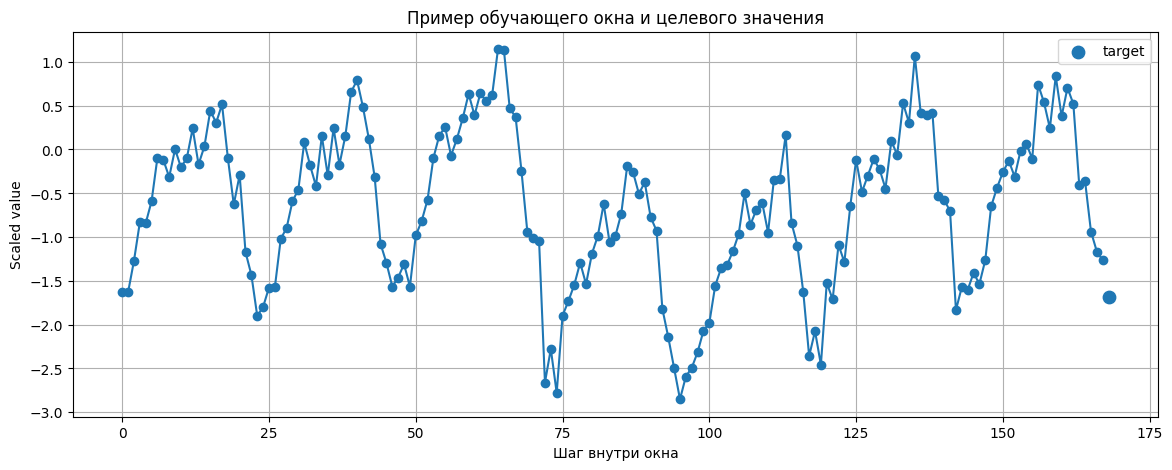

In [99]:
sample_idx = 0

print("Форма одного окна:", X_train[sample_idx].shape)
print("Первые 5 значений окна:", X_train[sample_idx][:5].ravel())
print("Цель:", y_train[sample_idx])

fig, ax = plt.subplots()
ax.plot(np.arange(window_size), X_train[sample_idx].ravel(), marker="o")
ax.scatter([window_size], [y_train[sample_idx]], s=80, label="target")
ax.set_title("Пример обучающего окна и целевого значения")
ax.set_xlabel("Шаг внутри окна")
ax.set_ylabel("Scaled value")
ax.legend()
plt.show()

In [100]:
# Определяем PyTorch Dataset для обработки последовательностей
class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset для использования с DataLoader."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (num_samples, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (num_samples,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64  # Размер батча для градиентного спуска

# Создаем датасеты для каждого набора
train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

# Создаем DataLoaders для итерирования по батчам
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)   # train перемешиваем
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)      # val не перемешиваем
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Проверяем форму батча
xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  # (batch_size, window_size, 1)
print("Batch y:", yb.shape)  # (batch_size,)

Batch X: torch.Size([64, 168, 1])
Batch y: torch.Size([64])


In [101]:
class GRUForecaster(nn.Module):
    """
    GRU-модель для временных рядов.
    GRU проще, чем LSTM: имеет 2 вентиля (reset и update) вместо 3, нет cell state.
    Часто работает лучше на малых датасетах благодаря меньшей сложности оптимизации.
    """
    def __init__(self, input_size: int = 1, hidden_size: int = 48, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred
    
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучает модель на одной эпохе.
    1. Переводим в режим train
    2. Проходим по всем батчам
    3. Вычисляем loss и обновляем веса
    4. Возвращаем среднее значение loss
    """
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """
    Оценивает модель на валидации/тесте без обновления весов.
    @torch.no_grad() отключает вычисление градиентов (экономит память и время).
    """
    model.eval()  # Режим оценки (отключаем dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))



def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучает модель на одной эпохе.
    1. Переводим в режим train
    2. Проходим по всем батчам
    3. Вычисляем loss и обновляем веса
    4. Возвращаем среднее значение loss
    """
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """
    Оценивает модель на валидации/тесте без обновления весов.
    @torch.no_grad() отключает вычисление градиентов (экономит память и время).
    """
    model.eval()  # Режим оценки (отключаем dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=device):
    """
    Полный цикл обучения с ранней остановкой.
    Сохраняет лучшее состояние модели (когда val_loss был минимален).
    """
    criterion = nn.MSELoss()  # Mean Squared Error loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam optimizer

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # 1. Обучение на train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        # 2. Оценка на validation
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # 3. Отслеживаем лучший результат
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()  # Сохраняем веса при лучшем val_loss

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем и сохраняем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(best_state, "artifacts/best_gru.pt")

    return history


@torch.no_grad()
def predict_model(model, loader, device):
    """
    Получает предсказания модели на батчах.
    Возвращает предсказания и истинные значения (в масштабированном пространстве).
    """
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Преобразует нормализованные значения обратно в исходный масштаб."""
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


GRU  params: 37889
Epoch 01 | train_loss=0.6745 | val_loss=0.5663
Epoch 02 | train_loss=0.2626 | val_loss=0.2800
Epoch 03 | train_loss=0.1662 | val_loss=0.1861
Epoch 04 | train_loss=0.1526 | val_loss=0.1876
Epoch 05 | train_loss=0.1503 | val_loss=0.2108
Epoch 06 | train_loss=0.1489 | val_loss=0.1843
Epoch 07 | train_loss=0.1450 | val_loss=0.1985
Epoch 08 | train_loss=0.1419 | val_loss=0.2545
Epoch 09 | train_loss=0.1429 | val_loss=0.1968
Epoch 10 | train_loss=0.1408 | val_loss=0.2135
Epoch 11 | train_loss=0.1387 | val_loss=0.1686
Epoch 12 | train_loss=0.1345 | val_loss=0.2344
Epoch 13 | train_loss=0.1257 | val_loss=0.1702
Epoch 14 | train_loss=0.1136 | val_loss=0.1931
Epoch 15 | train_loss=0.1070 | val_loss=0.1501
Epoch 16 | train_loss=0.1054 | val_loss=0.1671
Epoch 17 | train_loss=0.1029 | val_loss=0.1773
Epoch 18 | train_loss=0.1011 | val_loss=0.1731
Epoch 19 | train_loss=0.0999 | val_loss=0.1824
Epoch 20 | train_loss=0.0990 | val_loss=0.1742
Epoch 21 | train_loss=0.0984 | val_loss=0

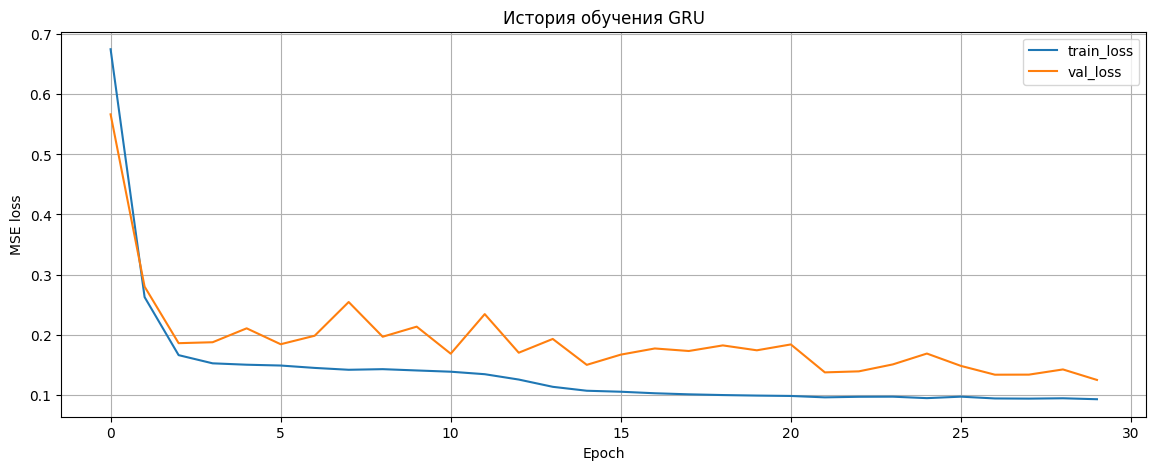

In [102]:
# Обучение GRU
epochs = 30
lr = 5e-4
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=epochs, lr=lr, device=device)
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.savefig("artifacts/figures/gru_learning_curves.png")
plt.show()

In [103]:
experiment_id = "R1"

gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)
val_pred_gru = inverse_scale(gru_val_pred_scaled, scaler)
y_val = inverse_scale(y_val, scaler)

metrics_r1 = evaluate_regression(y_val, val_pred_gru)
print(metrics_r1)

{'MAE': 5.005121231079102, 'RMSE': 6.534182825459753, 'MAPE': 3.404290199279785}


Лучшая модель по MAE на val - GRU, поэтому считаем метрики на test для нее. 

In [104]:
gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, device)
test_pred_gru = inverse_scale(gru_test_pred_scaled, scaler)
test_true = inverse_scale(gru_test_true_scaled, scaler)
test_metrics_r1 = evaluate_regression(test_true, test_pred_gru)
print(test_metrics_r1)

save_results({
    "experiment_id": experiment_id, 
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": "temporal split 70/15/15", 
    "window_size": window_size,
    "horizon": "", 
    "model_summary": "GRU (hidden_size=64, num_layers=2)",
    "features_summary": "", 
    "scaler": "StandartScaler", 
    "optimizer": "Adam", 
    "lr": lr, 
    "epochs_trained": epochs, 
    "best_val_mae": metrics_r1['MAE'], 
    "best_val_rmse": metrics_r1['RMSE'], 
    "best_val_mape": metrics_r1['MAPE'],
    "test_mae" : test_metrics_r1['MAE'],
    "test_rmse" : test_metrics_r1['RMSE'],
    "test_mape": test_metrics_r1['MAPE'], 
    "notes": ""
})

{'MAE': 5.508685111999512, 'RMSE': 7.162000719280788, 'MAPE': 3.5691077709198}


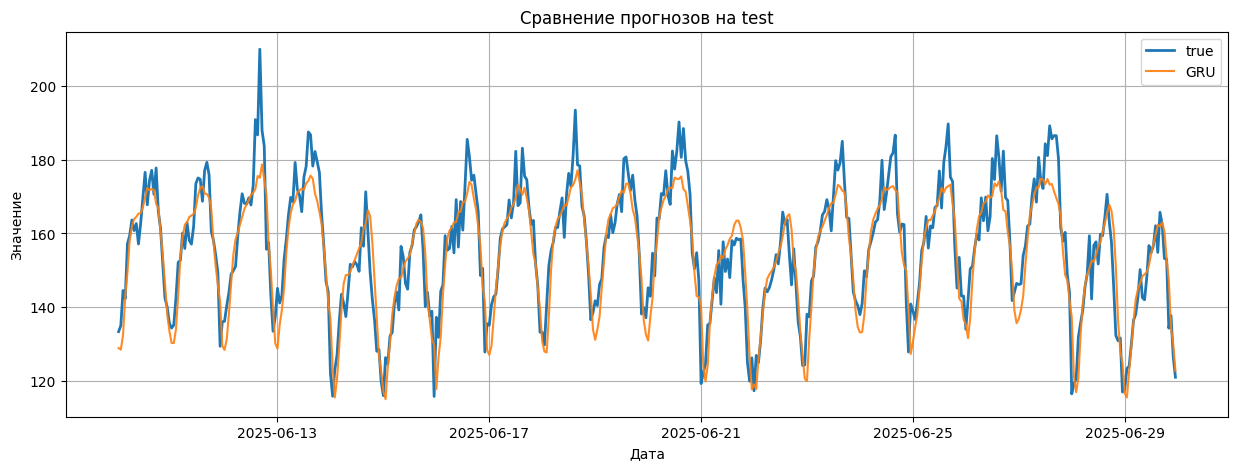

In [106]:
# Строим график прогноза на test для GRU
plot_df = pd.DataFrame(
    {
        "date": test_df["date"].iloc[window_size:].reset_index(drop=True),
        "true": test_true,
        "gru": test_pred_gru,
    }
)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(plot_df["date"], plot_df["true"], label="true", lw=2)
ax.plot(plot_df["date"], plot_df["gru"], label="GRU", alpha=0.9)
ax.set_title("Сравнение прогнозов на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.savefig("artifacts/figures/best_forecast_test.png")
plt.show()

In [107]:
import json


best_config = {
    "architecture": "GRU",
    "window_size": window_size,
    "hidden_size": 64,
    "batch_size": batch_size,
    "learning_rate": lr,
    "seed": SEED,
    "scaler": "StandartScaler",
    "optimizer": "Adam",
    "epochs_trained": epochs
}

with open("artifacts/best_gru_config.json", 'w', encoding="utf-8") as f:
    json.dump(best_config, f, indent=4)

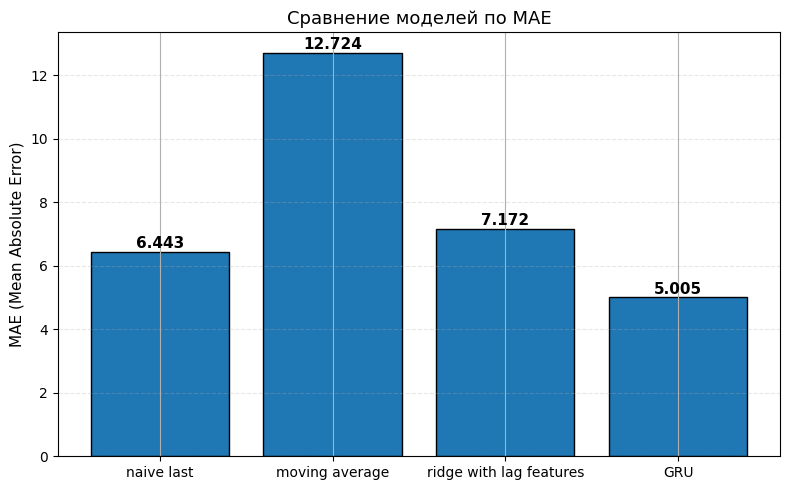

In [117]:
models = ['naive last', 'moving average', 'ridge with lag features', 'GRU']  # ← замените на ваши названия
mae_values = [
    metrics_b1['MAE'],
    metrics_b2['MAE'],
    metrics_b3['MAE'],
    metrics_r1['MAE']
]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, mae_values, edgecolor='black')

# Подписи значений на столбцах
for bar, val in zip(bars, mae_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylabel('MAE (Mean Absolute Error)', fontsize=11)
plt.title('Сравнение моделей по MAE', fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("artifacts/figures/baselines_compare.png")
plt.show()